## LIAR Dataset

This is a benchmark for individual statements (not full articles), so this model/classifier will look at 2 methods to supervised classification.
1. Maintain the classifications that were given by the dataset source (`barely-true`, `false`, `half-true`, `true`, `mostly-true`, `pants-fire`) - using alternative methods that may involve the other data that we have
2. perform binary classification, aka splitting the classes into `true` and `false` - Using `SGDClassifier`?

In [2]:
import pandas as pd
import numpy as np
import re
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV

In [3]:
df = pd.read_table('../data/liar_dataset/train.tsv')
df.reset_index(inplace=True)
df.head()

,level_0,level_1,level_2,level_3,level_4,level_5,level_6,level_7,level_8,level_9,level_10,level_11,level_12,ID
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


In [4]:
row = np.array(df.columns)
row

array(['level_0', 'level_1', 'level_2', 'level_3', 'level_4', 'level_5',
       'level_6', 'level_7', 'level_8', 'level_9', 'level_10', 'level_11',
       'level_12', 'ID'], dtype=object)

In [5]:
cols = pd.Index(['ID', 'label', 'statement', 'subject', 'speaker', "speakers job", "state", "party/affiliation", "barely-true count", "false count", "half-true count", "mostly-true count", "pants-fire count", "context"], dtype='object')
cols

Index(['ID', 'label', 'statement', 'subject', 'speaker', 'speakers job',
       'state', 'party/affiliation', 'barely-true count', 'false count',
       'half-true count', 'mostly-true count', 'pants-fire count', 'context'],
      dtype='object')

In [6]:
df.columns = cols

In [7]:
df['length'] = df['statement'].apply(len)
df.head()

,ID,label,statement,subject,speaker,speakers job,state,party/affiliation,barely-true count,false count,half-true count,mostly-true count,pants-fire count,context,length
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer,82
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.,141
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver,105
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release,78
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN,54


In [8]:
df['length'].describe()

count    10240.000000
mean       106.918750
std         59.917722
min         11.000000
25%         73.000000
50%         99.000000
75%        132.250000
max       3192.000000
Name: length, dtype: float64

In [9]:
df.nsmallest(1, 'length')

,ID,label,statement,subject,speaker,speakers job,state,party/affiliation,barely-true count,false count,half-true count,mostly-true count,pants-fire count,context,length
709,5919.json,false,On abortion,"abortion,corrections-and-updates",mitt-romney,Former governor,Massachusetts,republican,34.0,32.0,58.0,33.0,19.0,various statements,11


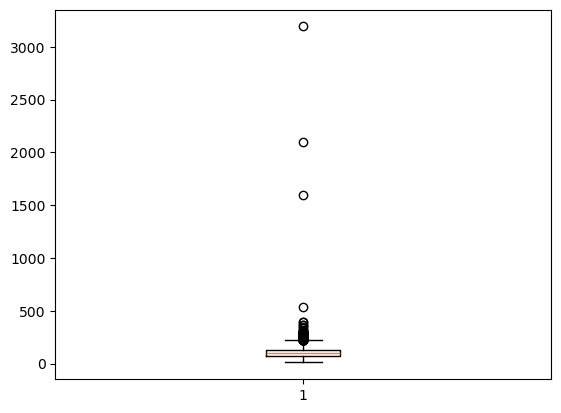

In [10]:
plt.boxplot(x=df['length'])
plt.show()

## Keeping label classes

learn this eventually!

In [11]:
df['label'].value_counts()

label
half-true      2114
false          1995
mostly-true    1962
true           1676
barely-true    1654
pants-fire      839
Name: count, dtype: int64

## Turning into binary classifier

In [12]:
df_bin = df
df_bin = df_bin.drop(columns=['ID', 'subject', 'speaker', "speakers job", "state", "party/affiliation", "barely-true count", "false count", "half-true count", "mostly-true count", "pants-fire count", "context"])

In [13]:
df_bin['real_label'] = df_bin['label'].map({"half-true": 1, "false": 1, "mostly-true": 0, "true": 0, "barely-true": 1, "pants-fire": 1})
df_bin['real_label'].value_counts()

real_label
1    6602
0    3638
Name: count, dtype: int64

In [14]:
df_true = df_bin[df_bin['real_label'] == 0]
df_false = df_bin[df_bin['real_label'] == 1]
df_true = df_true